In [1]:
# ============================================================
# RETO 9 — Modelo 4: Red Neuronal (Deep Learning)
# Ejecutar en Google Colab con GPU
# ============================================================

# --- 1. Verificar GPU ---
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

# --- 2. Subir los archivos ---
from google.colab import files
print("\n📁 Sube los 4 archivos: X_train.csv, X_test.csv, y_train.csv, y_test.csv")
uploaded = files.upload()

TensorFlow: 2.20.0
GPU disponible: []

📁 Sube los 4 archivos: X_train.csv, X_test.csv, y_train.csv, y_test.csv


Saving X_test.csv to X_test.csv
Saving X_train.csv to X_train.csv
Saving y_test.csv to y_test.csv
Saving y_train.csv to y_train.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

sns.set_style("whitegrid")

# --- Carga de datos ---
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Churn en train: {y_train.mean()*100:.2f}%")

Train: (5634, 26) | Test: (1409, 26)
Churn en train: 26.54%


In [3]:
# ============================================================
# CONSTRUCCIÓN DE LA RED NEURONAL
# ============================================================

# --- Calcular class_weight para el desbalance ---
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weights_dict}")

# --- Arquitectura de la red ---
model = Sequential([
    # Capa de entrada + primera capa oculta
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    # Segunda capa oculta
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Tercera capa oculta
    Dense(16, activation='relu'),
    Dropout(0.2),

    # Capa de salida (clasificación binaria)
    Dense(1, activation='sigmoid')
])

# --- Compilar ---
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

# --- Callbacks ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# --- Entrenamiento ---
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6051 - auc: 0.7097 - loss: 0.6774 - val_accuracy: 0.7675 - val_auc: 0.8023 - val_loss: 0.5025 - learning_rate: 0.0010
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6858 - auc: 0.7848 - loss: 0.5702 - val_accuracy: 0.7267 - val_auc: 0.8152 - val_loss: 0.4980 - learning_rate: 0.0010
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7129 - auc: 0.8074 - loss: 0.5445 - val_accuracy: 0.7223 - val_auc: 0.8188 - val_loss: 0.5110 - learning_rate: 0.0010
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7182 - auc: 0.8082 - loss: 0.5382 - val_accuracy: 0.7143 - val_auc: 0.8207 - val_loss: 0.5301 - learning_rate: 0.0010
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7302 - auc: 0.8262 - loss: 0.5161 - val_accuracy: 0.7169 - val_auc: 0.8242 - val_loss: 0.5073 - learning_rate: 0.0010
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7386 - a

In [4]:
# ============================================================
# EVALUACIÓN DEL MODELO
# ============================================================

y_pred_proba = model.predict(X_test).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("EVALUACIÓN DE LA RED NEURONAL")
print("=" * 60)
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print("\n--- Reporte completo ---")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
EVALUACIÓN DE LA RED NEURONAL

Accuracy:  0.7516
Precision: 0.5221
Recall:    0.7594
F1-score:  0.6187
AUC-ROC:   0.8310

--- Reporte completo ---
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



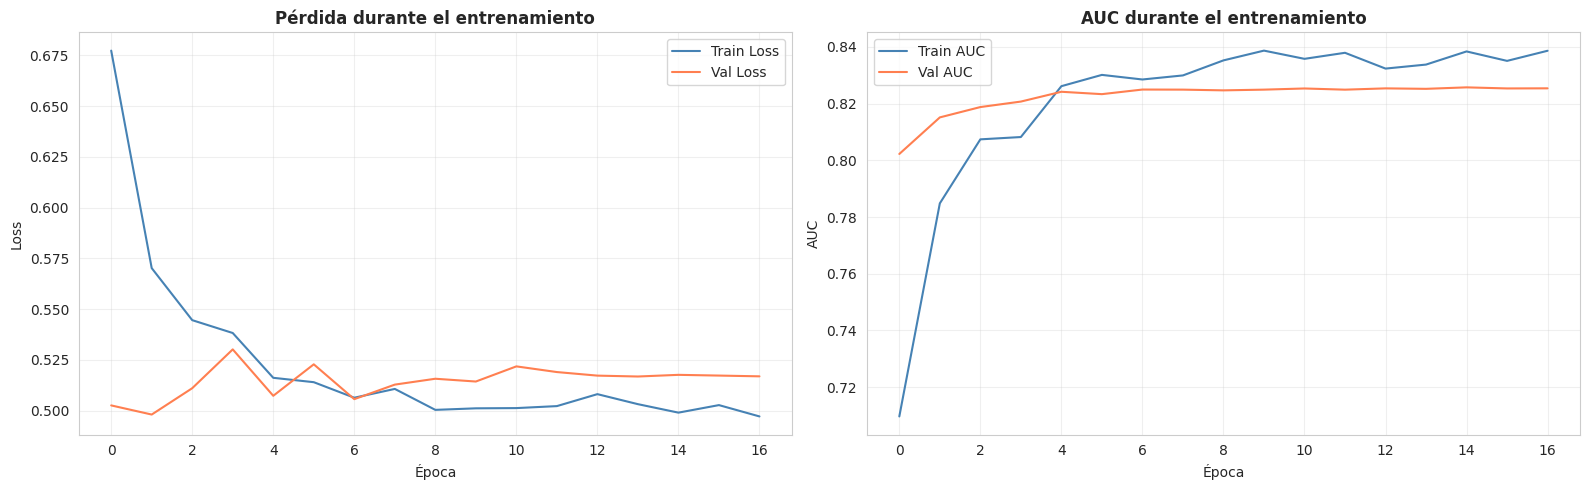

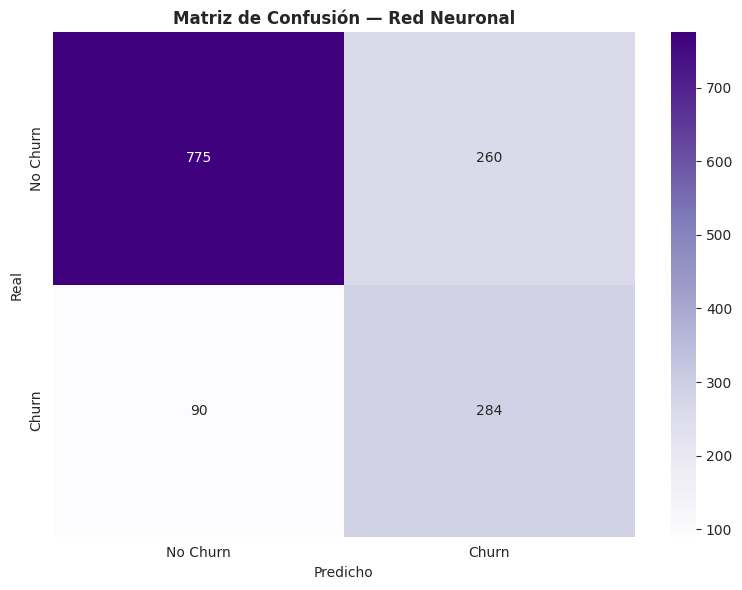

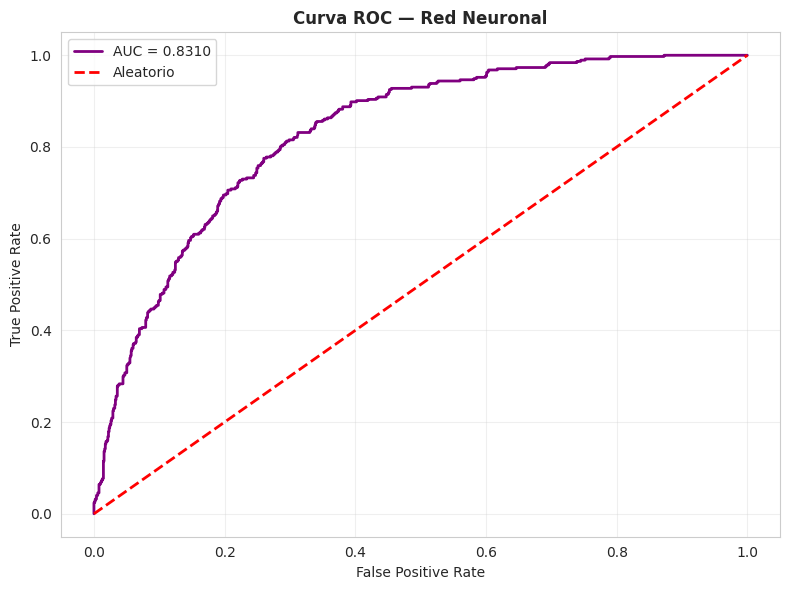

✅ Figuras generadas


In [5]:
# ============================================================
# VISUALIZACIONES
# ============================================================

# --- 1. Curvas de aprendizaje ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('Pérdida durante el entrenamiento', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# AUC
axes[1].plot(history.history['auc'], label='Train AUC', color='steelblue')
axes[1].plot(history.history['val_auc'], label='Val AUC', color='coral')
axes[1].set_title('AUC durante el entrenamiento', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('15_curvas_entrenamiento.png', dpi=100, bbox_inches='tight')
plt.show()

# --- 2. Matriz de confusión ---
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
ax.set_title('Matriz de Confusión — Red Neuronal', fontweight='bold')
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig('16_confusion_red_neuronal.png', dpi=100, bbox_inches='tight')
plt.show()

# --- 3. Curva ROC ---
fig, ax = plt.subplots(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax.plot(fpr, tpr, color='purple', linewidth=2, label=f'AUC = {auc:.4f}')
ax.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Aleatorio')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curva ROC — Red Neuronal', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('17_roc_red_neuronal.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Figuras generadas")

In [6]:
# ============================================================
# GUARDAR MODELO Y DESCARGAR ARCHIVOS
# ============================================================

# Guardar modelo en formato Keras
model.save('modelo_red_neuronal.keras')
print("✅ Modelo guardado: modelo_red_neuronal.keras")

# Descargar los archivos a tu ordenador
from google.colab import files
files.download('modelo_red_neuronal.keras')
files.download('15_curvas_entrenamiento.png')
files.download('16_confusion_red_neuronal.png')
files.download('17_roc_red_neuronal.png')
print("\n✅ Archivos descargados")

✅ Modelo guardado: modelo_red_neuronal.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Archivos descargados
